# 🧬 Metabolomics & Clinical Analysis — Sheet3

**Dataset structure:**
- 265 rows × 66 columns (1 embedded header row → 264 usable samples after cleaning)
- **103 unique patients**, up to 3 timepoints each (T1 / T2 / T3)
- **3 treatment arms:** T (exercise training), K (control), E (nutrition)
- **35 raw metabolite intensities** (GC-MS peak areas, log-normal distributed)
- **17 clinical / physical performance features** (grip strength, gait speed, BMI, …)
- **Targets:** `2group`, `4group`, `6group` (physical activity classification)

**Pipeline:**
1. Cleaning & type coercion
2. Modality-aware preprocessing — log + batch correction for metabolites; standard scaling for clinical
3. Autoencoder on metabolites (noise reduction → compressed representation)
4. Multi-modal feature fusion (clinical + encoded metabolites)
5. Classification with 5-fold CV, comparing modalities in isolation vs fused
6. Feature importance with modality attribution
7. Longitudinal trajectory analysis by treatment arm

---
### ⚙️ Configuration

In [1]:
EXCEL_FILE   = "41540_2025_580_MOESM2_ESM.xlsx"
DATA_SHEET   = "Sheet3"

# Classification target: '2group', '4group', or '6group'
TARGET_COL   = "2group"

# Autoencoder
ENCODING_DIM = 12
AE_EPOCHS    = 100
AE_BATCH     = 32

TEST_SIZE    = 0.2
RANDOM_STATE = 42

## 1 · Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import sklearn.model_selection
import sklearn.preprocessing
import sklearn.impute
import sklearn.linear_model
import sklearn.ensemble
import sklearn.svm
import sklearn.metrics
import sklearn.decomposition

import torch
import torch.nn
import torch.utils.data
import torch.optim
import torch.optim.lr_scheduler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print(f'PyTorch {torch.__version__} | device={DEVICE} | pandas {pd.__version__}')

PyTorch 2.7.1 | device=cpu | pandas 3.0.0


## 2 · Load & Clean

In [3]:
df_raw = pd.read_excel(EXCEL_FILE, sheet_name=DATA_SHEET)

# Drop the embedded header row (last row contains column-name strings, not data)
df_raw = df_raw[pd.to_numeric(df_raw['Patient_ID'], errors='coerce').notna()].copy()
df_raw['Patient_ID'] = df_raw['Patient_ID'].astype(int)

# Coerce object columns that should be numeric
for col in ['handgrip_left', 'BMI', '**Linoleic acid']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Normalise gender label ('male ' -> 'male')
df_raw['gender'] = df_raw['gender'].str.strip()

# Drop duplicate hip/whr columns (hip.1, whr.1 are identical to hip, whr)
df_raw = df_raw.drop(columns=['hip.1', 'whr.1'])

# Coerce targets to numeric
for col in ['2group', '4group', '6group']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Drop dropout arm — no treatment label and very small group (n=11)
df_raw = df_raw[df_raw['treatment'] != 'dropout'].reset_index(drop=True)

# Strip leading * / ** from metabolite column names for readability
df_raw.columns = [c.lstrip('*').strip() for c in df_raw.columns]

print(f'Clean shape   : {df_raw.shape}')
print(f'Patients      : {df_raw["Patient_ID"].nunique()}')
print(f'Timepoints    : {df_raw["timepoint"].value_counts().to_dict()}')
print(f'Treatment arms: {df_raw["treatment"].value_counts().to_dict()}')
print(f'Target ({TARGET_COL}): {df_raw[TARGET_COL].value_counts().to_dict()}')

Clean shape   : (252, 64)
Patients      : 93
Timepoints    : {'T1': 91, 'T2': 87, 'T3': 74}
Treatment arms: {'T': 91, 'K': 86, 'E': 75}
Target (2group): {2.0: 146, 1.0: 106}


## 3 · Define Feature Groups

In [4]:
# Metabolites: originally prefixed with * or ** — now stripped
META_COLS = [
    'Cholesterol', 'Linoleic acid', 'alpha-Tocopherol',
    'Alanine total', 'Asparagine (3TMS)', 'Aspartic acid (3TMS)',
    'Citric acid (4TMS)', 'Fructose total', 'Fumaric acid (2TMS)',
    'Galactose MP', 'Glucose total', 'Glutamic acid total',
    'Glutamine (3TMS)', 'Glutaric acid, 2-oxo-', 'Glycine total',
    'Isoleucine total', 'Lactic acid', 'Leucine total',
    'Lysine (4TMS)', 'Malic acid (3TMS)', 'Methionine total',
    'Ornithine total', 'Palmitic acid', 'Phenylalanine total',
    'Proline (2TMS)', 'Proline total', 'Pyruvic acid',
    'Serine total', 'Succinic acid (2TMS)', 'Threitol (4TMS)',
    'Threonic acid (4TMS)', 'Threonine total', 'Tyrosine total',
    'Valine total', 'myo-Inositol',
]
# Keep only those actually present after name-stripping
META_COLS = [c for c in META_COLS if c in df_raw.columns]

CLINICAL_COLS = [
    'legstand_right', 'legstand_left',
    'handgrip_left', 'handgrip_right',
    'heben_light', 'heben_schwer',
    'walkspeed', 'chairrise', 'walkdistance', 'walking_Category',
    'phasenwinkel', 'weight', 'height', 'BMI', 'waist', 'hip', 'whr',
]

print(f'Metabolite features : {len(META_COLS)}')
print(f'Clinical features   : {len(CLINICAL_COLS)}')

Metabolite features : 35
Clinical features   : 17


## 4 · Modality-Aware Preprocessing

The two modalities need fundamentally different treatment:

- **Metabolites** — raw GC-MS peak areas span several orders of magnitude and follow a log-normal distribution. Pipeline: `log1p → batch mean-ratio correction → median imputation → standard scaling`.
- **Clinical** — physical performance measures already on human scales (kg, m/s, cm, …). Pipeline: `median imputation → standard scaling`.
- **Demographics** — age (z-scored) and gender (binary-encoded) appended as additional features.

In [7]:
df = df_raw.copy()

# ── 4.1  Metabolite preprocessing ─────────────────────────────────────
# Log1p transform to stabilise variance
df[META_COLS] = np.log1p(df[META_COLS].apply(pd.to_numeric, errors='coerce'))

# Batch mean-ratio correction (mirrors the procedure documented in Sheet4)
grand_means = df[META_COLS].mean()
for batch in df['batch'].dropna().unique():
    mask = df['batch'] == batch
    batch_means = df.loc[mask, META_COLS].mean()
    ratio = grand_means / batch_means.replace(0, np.nan)
    df.loc[mask, META_COLS] = df.loc[mask, META_COLS] * ratio

# Median impute then standard scale
meta_imputer = sklearn.impute.SimpleImputer(strategy='median')
meta_scaler  = sklearn.preprocessing.StandardScaler()
df[META_COLS] = meta_scaler.fit_transform(
    meta_imputer.fit_transform(df[META_COLS])
)

# ── 4.2  Clinical preprocessing ───────────────────────────────────────
clinical_imputer = sklearn.impute.SimpleImputer(strategy='median')
clinical_scaler  = sklearn.preprocessing.StandardScaler()
df[CLINICAL_COLS] = clinical_scaler.fit_transform(
    clinical_imputer.fit_transform(
        df[CLINICAL_COLS].apply(pd.to_numeric, errors='coerce')
    )
)

# ── 4.3  Demographics ─────────────────────────────────────────────────
age_vals = pd.to_numeric(df['age'], errors='coerce').fillna(df['age'].median()).values.reshape(-1, 1)
df['age_z']      = sklearn.preprocessing.StandardScaler().fit_transform(age_vals)
df['gender_enc'] = (df['gender'] == 'female').astype(float)
DEMO_COLS = ['age_z', 'gender_enc']

# ── 4.4  Target ───────────────────────────────────────────────────────
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
le = sklearn.preprocessing.LabelEncoder()
y  = le.fit_transform(df[TARGET_COL].astype(int))

print(f'Preprocessing complete. Samples: {len(df)}')
print(f'Classes: {dict(enumerate(le.classes_))}')
print(f'Class balance: {pd.Series(y).value_counts().to_dict()}')

Preprocessing complete. Samples: 252
Classes: {0: np.int64(1), 1: np.int64(2)}
Class balance: {1: 146, 0: 106}


## 5 · Metabolite Autoencoder (Noise Reduction)

An autoencoder is trained on the 35 log-scaled, batch-corrected metabolite features to produce a compressed `ENCODING_DIM`-dimensional representation. This acts as a learned denoising step before fusion with clinical data — particularly useful given the small sample size relative to the number of metabolites.

Epoch  20  train=1.03783  val=1.10844
Early stopping at epoch 22


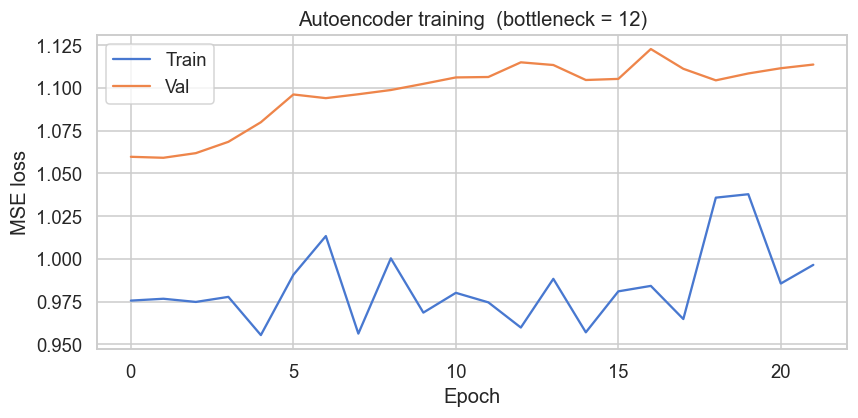

In [10]:
X_meta    = df[META_COLS].values.astype(np.float32)
input_dim = X_meta.shape[1]

class Autoencoder(torch.nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 64), torch.nn.ReLU(),
            torch.nn.BatchNorm1d(64),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, 32), torch.nn.ReLU(),
            torch.nn.BatchNorm1d(32),
            torch.nn.Linear(32, encoding_dim), torch.nn.ReLU(),
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(encoding_dim, 32), torch.nn.ReLU(),
            torch.nn.BatchNorm1d(32),
            torch.nn.Linear(32, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)

val_n    = int(0.1 * len(X_meta))
X_ae_tr  = torch.tensor(X_meta[val_n:])
X_ae_val = torch.tensor(X_meta[:val_n])

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_ae_tr, X_ae_tr),
    batch_size=AE_BATCH, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_ae_val, X_ae_val),
    batch_size=AE_BATCH
)

ae_model  = Autoencoder(input_dim, ENCODING_DIM).to(DEVICE)
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
criterion = torch.nn.MSELoss()

best_val, patience_cnt, best_state = float('inf'), 0, None
train_losses, val_losses = [], []

for epoch in range(1, AE_EPOCHS + 1):
    ae_model.train()
    t_loss = sum(
        criterion(ae_model(xb.to(DEVICE)), yb.to(DEVICE)).item()
        for xb, yb in train_loader
    ) / len(train_loader)

    ae_model.eval()
    with torch.no_grad():
        v_loss = sum(
            criterion(ae_model(xb.to(DEVICE)), yb.to(DEVICE)).item()
            for xb, yb in val_loader
        ) / len(val_loader)

    scheduler.step(v_loss)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val     = v_loss
        best_state   = {k: v.cpu().clone() for k, v in ae_model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= 20:
            print(f'Early stopping at epoch {epoch}')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}  train={t_loss:.5f}  val={v_loss:.5f}')

ae_model.load_state_dict(best_state)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title(f'Autoencoder training  (bottleneck = {ENCODING_DIM})')
ax.legend()
plt.tight_layout(); plt.show()

In [11]:
def encode_np(X_np):
    ae_model.eval()
    with torch.no_grad():
        t = torch.tensor(X_np.astype(np.float32)).to(DEVICE)
        return ae_model.encode(t).cpu().numpy()

X_meta_enc = encode_np(X_meta)

recon = ae_model(torch.tensor(X_meta).to(DEVICE)).detach().cpu().numpy()
print(f'Encoded shape    : {X_meta_enc.shape}')
print(f'Reconstruction MSE: {sklearn.metrics.mean_squared_error(X_meta, recon):.5f}')

Encoded shape    : (252, 12)
Reconstruction MSE: 1.00347


## 6 · Latent Space Visualisation

PCA projection of the autoencoder bottleneck, coloured by treatment arm, timepoint, and target class. This reveals whether the compressed metabolite representation captures biologically meaningful structure.

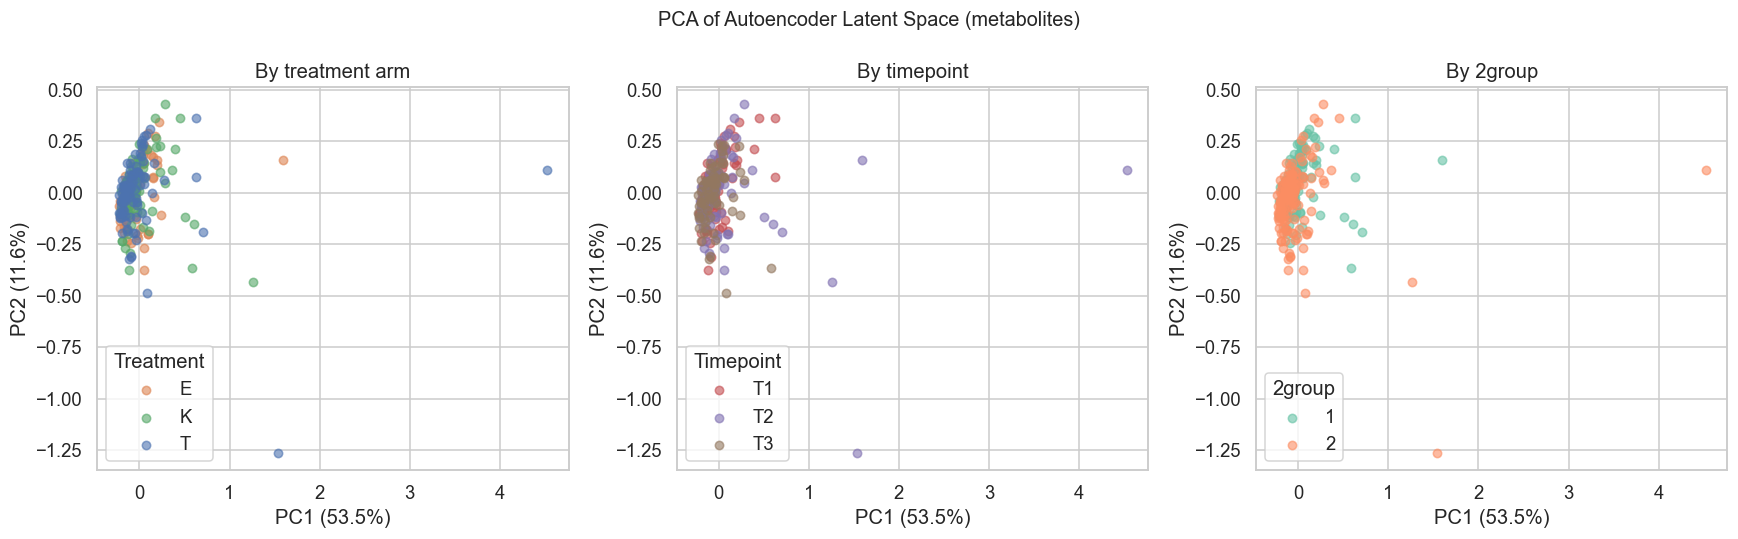

In [12]:
pca       = sklearn.decomposition.PCA(n_components=2)
X_meta_2d = pca.fit_transform(X_meta_enc)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette_trt = {'T': '#4c72b0', 'K': '#55a868', 'E': '#dd8452'}
palette_tp  = {'T1': '#c44e52', 'T2': '#8172b2', 'T3': '#937860'}
palette_cls = sns.color_palette('Set2', len(le.classes_))

for arm, grp in df.groupby('treatment'):
    idx = grp.index
    axes[0].scatter(X_meta_2d[idx, 0], X_meta_2d[idx, 1],
                    label=arm, alpha=0.6, s=30, color=palette_trt.get(arm, 'grey'))
axes[0].set_title('By treatment arm')
axes[0].legend(title='Treatment')

for tp, grp in df.groupby('timepoint'):
    idx = grp.index
    axes[1].scatter(X_meta_2d[idx, 0], X_meta_2d[idx, 1],
                    label=tp, alpha=0.6, s=30, color=palette_tp.get(tp, 'grey'))
axes[1].set_title('By timepoint')
axes[1].legend(title='Timepoint')

for cls_idx, cls_name in enumerate(le.classes_):
    mask = y == cls_idx
    axes[2].scatter(X_meta_2d[mask, 0], X_meta_2d[mask, 1],
                    label=str(cls_name), alpha=0.6, s=30, color=palette_cls[cls_idx])
axes[2].set_title(f'By {TARGET_COL}')
axes[2].legend(title=TARGET_COL)

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

plt.suptitle('PCA of Autoencoder Latent Space (metabolites)', fontsize=13)
plt.tight_layout(); plt.show()

## 7 · Multi-Modal Feature Fusion & Classification

Three feature sets are compared to isolate the contribution of each modality:

| Set | Contents |
|-----|----------|
| `clinical` | 17 clinical + 2 demographic features |
| `metabolites` | 12-dim autoencoder encoding |
| `fused` | clinical + demographics + encoded metabolites |

All models are evaluated with 5-fold stratified cross-validation.

In [13]:
X_clinical = df[CLINICAL_COLS + DEMO_COLS].values.astype(np.float32)

feature_sets = {
    'clinical'    : X_clinical,
    'metabolites' : X_meta_enc,
    'fused'       : np.hstack([X_clinical, X_meta_enc]),
}

models = {
    'Logistic Regression' : sklearn.linear_model.LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE, C=1.0),
    'Random Forest'       : sklearn.ensemble.RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : sklearn.ensemble.GradientBoostingClassifier(
        n_estimators=300, random_state=RANDOM_STATE, learning_rate=0.05),
    'SVM (RBF)'           : sklearn.svm.SVC(
        kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

cv = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
print(f'5-fold stratified CV  |  target: {TARGET_COL}\n')
print(f'{"Model":<25} {"Features":<14} {"BalAcc mean":>12} {"BalAcc std":>11}')
print('─' * 65)

for feat_name, X_feat in feature_sets.items():
    for model_name, model in models.items():
        scores = sklearn.model_selection.cross_val_score(
            copy.deepcopy(model), X_feat, y,
            cv=cv, scoring='balanced_accuracy', n_jobs=-1
        )
        results.append(dict(
            model=model_name, features=feat_name,
            mean=scores.mean(), std=scores.std()
        ))
        print(f'{model_name:<25} {feat_name:<14} {scores.mean():>12.4f} {scores.std():>11.4f}')
    print()

5-fold stratified CV  |  target: 2group

Model                     Features        BalAcc mean  BalAcc std
─────────────────────────────────────────────────────────────────
Logistic Regression       clinical             0.9325      0.0043
Random Forest             clinical             0.9429      0.0141
Gradient Boosting         clinical             0.9296      0.0268
SVM (RBF)                 clinical             0.8791      0.0349

Logistic Regression       metabolites          0.5713      0.0173
Random Forest             metabolites          0.5950      0.0457
Gradient Boosting         metabolites          0.6061      0.0757
SVM (RBF)                 metabolites          0.6187      0.0672

Logistic Regression       fused                0.9277      0.0091
Random Forest             fused                0.9463      0.0157
Gradient Boosting         fused                0.9227      0.0447
SVM (RBF)                 fused                0.8791      0.0349



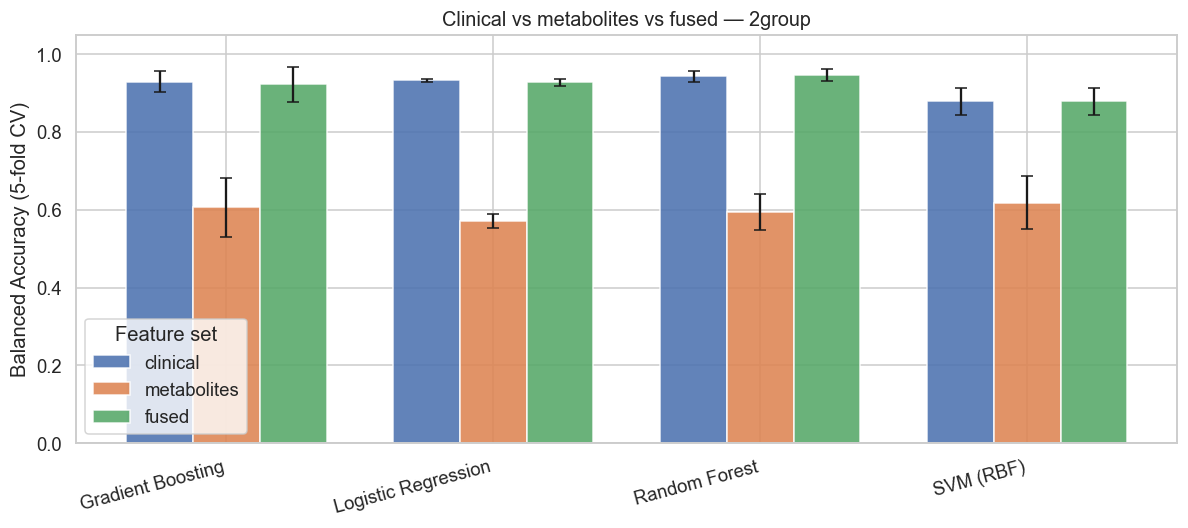

In [14]:
results_df  = pd.DataFrame(results)
pivot       = results_df.pivot(index='model', columns='features', values='mean')
pivot_std   = results_df.pivot(index='model', columns='features', values='std')

fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(pivot))
width  = 0.25
colors = ['#4c72b0', '#dd8452', '#55a868']

for i, feat in enumerate(['clinical', 'metabolites', 'fused']):
    ax.bar(x + i * width, pivot[feat], width,
           yerr=pivot_std[feat], capsize=4,
           label=feat, color=colors[i], alpha=0.88, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(pivot.index, rotation=15, ha='right')
ax.set_ylabel('Balanced Accuracy (5-fold CV)')
ax.set_title(f'Clinical vs metabolites vs fused — {TARGET_COL}', fontsize=13)
ax.legend(title='Feature set')
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

## 8 · Feature Importance — Fused Model

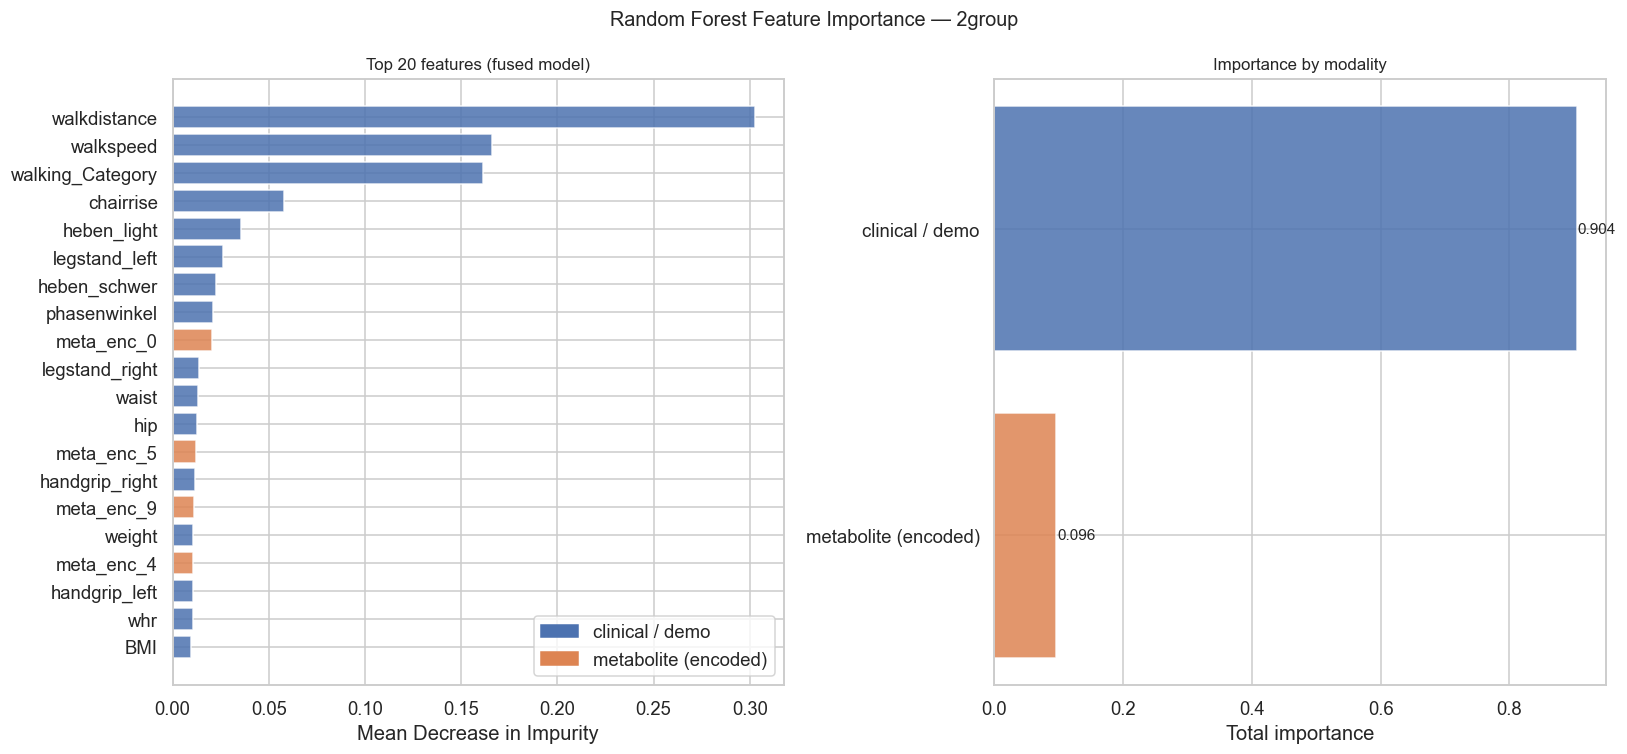


Top 10 features:
         feature             modality  importance
    walkdistance      clinical / demo    0.302623
       walkspeed      clinical / demo    0.165957
walking_Category      clinical / demo    0.161238
       chairrise      clinical / demo    0.057875
     heben_light      clinical / demo    0.035401
   legstand_left      clinical / demo    0.026443
    heben_schwer      clinical / demo    0.022744
    phasenwinkel      clinical / demo    0.020850
      meta_enc_0 metabolite (encoded)    0.020430
  legstand_right      clinical / demo    0.013978


In [15]:
X_fused     = feature_sets['fused']
fused_names = (
    CLINICAL_COLS + DEMO_COLS +
    [f'meta_enc_{i}' for i in range(ENCODING_DIM)]
)

rf_fused = sklearn.ensemble.RandomForestClassifier(
    n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
)
rf_fused.fit(X_fused, y)

fi_df = pd.DataFrame({'feature': fused_names, 'importance': rf_fused.feature_importances_})
fi_df['modality'] = fi_df['feature'].apply(
    lambda f: 'metabolite (encoded)' if f.startswith('meta_enc') else 'clinical / demo'
)
fi_df = fi_df.sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top 20 features coloured by modality
top20      = fi_df.head(20)
bar_colors = ['#dd8452' if m == 'metabolite (encoded)' else '#4c72b0' for m in top20['modality']]
axes[0].barh(top20['feature'], top20['importance'], color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].set_title('Top 20 features (fused model)', fontsize=11)
axes[0].legend(handles=[
    Patch(color='#4c72b0', label='clinical / demo'),
    Patch(color='#dd8452', label='metabolite (encoded)')
])

# Importance aggregated by modality
mod_imp = fi_df.groupby('modality')['importance'].sum().sort_values()
axes[1].barh(mod_imp.index, mod_imp.values,
             color=['#dd8452', '#4c72b0'], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Total importance')
axes[1].set_title('Importance by modality', fontsize=11)
for i, v in enumerate(mod_imp.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle(f'Random Forest Feature Importance — {TARGET_COL}', fontsize=13)
plt.tight_layout(); plt.show()

print('\nTop 10 features:')
print(fi_df[['feature', 'modality', 'importance']].head(10).to_string(index=False))

## 9 · Longitudinal Trajectory Analysis

For the 71 patients with all 3 timepoints, we track how the first principal component of each modality evolves across T1 → T2 → T3 per treatment arm. Individual patient trajectories are shown in light, group means ± SEM in bold — revealing whether the interventions diverge metabolically or functionally over time.

Patients with all 3 timepoints: 70


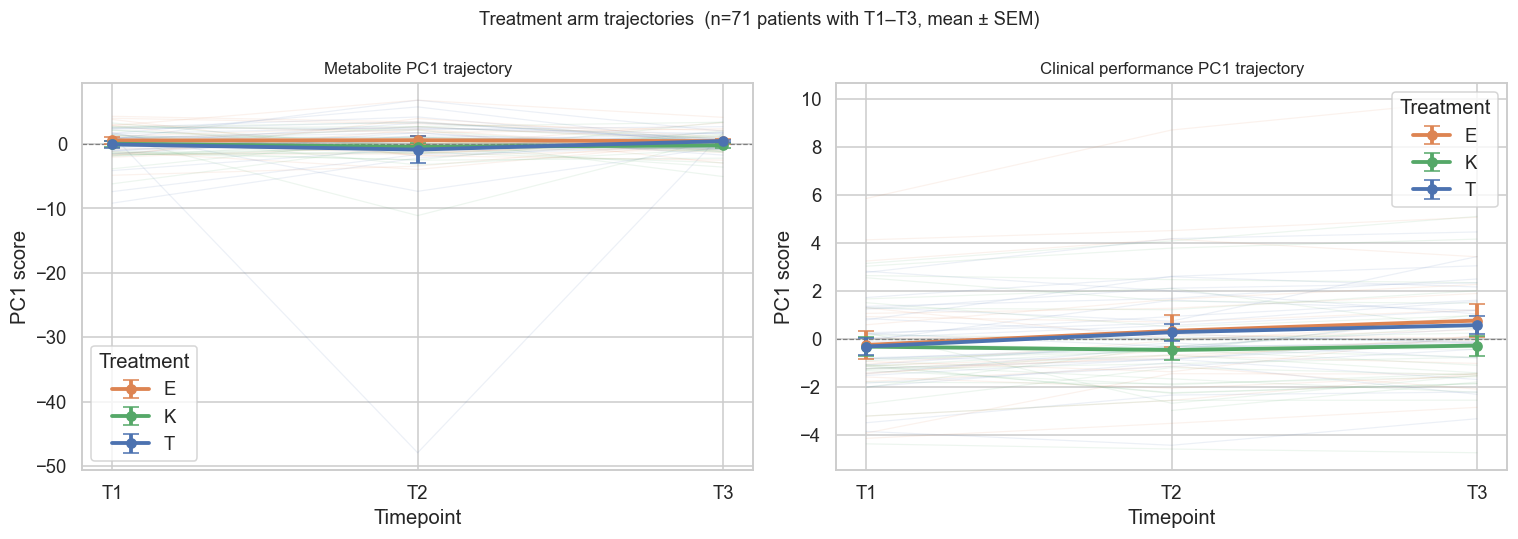

In [16]:
tp_counts     = df.groupby('Patient_ID')['timepoint'].nunique()
full_patients = tp_counts[tp_counts == 3].index
df_long       = df[df['Patient_ID'].isin(full_patients)].copy()
print(f'Patients with all 3 timepoints: {len(full_patients)}')

# PC1 of preprocessed metabolites and clinical features
pca_meta = sklearn.decomposition.PCA(n_components=1)
pca_clin = sklearn.decomposition.PCA(n_components=1)
df_long['meta_PC1'] = pca_meta.fit_transform(df_long[META_COLS].values)[:, 0]
df_long['clin_PC1'] = pca_clin.fit_transform(df_long[CLINICAL_COLS].values)[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tp_order = ['T1', 'T2', 'T3']

for ax, score_col, title in zip(
    axes,
    ['meta_PC1', 'clin_PC1'],
    ['Metabolite PC1 trajectory', 'Clinical performance PC1 trajectory']
):
    for arm, arm_df in df_long.groupby('treatment'):
        # Individual patient lines
        for pid, pat_df in arm_df.groupby('Patient_ID'):
            vals = pat_df.set_index('timepoint')[score_col].reindex(tp_order)
            ax.plot(tp_order, vals, color=palette_trt[arm], alpha=0.1, linewidth=0.8)
        # Group mean ± SEM
        means = arm_df.groupby('timepoint')[score_col].mean().reindex(tp_order)
        sems  = arm_df.groupby('timepoint')[score_col].sem().reindex(tp_order)
        ax.errorbar(tp_order, means, yerr=sems, marker='o', linewidth=2.5,
                    label=arm, color=palette_trt[arm], capsize=5, zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Timepoint')
    ax.set_ylabel('PC1 score')
    ax.legend(title='Treatment')
    ax.axhline(0, color='grey', lw=0.8, ls='--')

plt.suptitle(
    'Treatment arm trajectories  (n=71 patients with T1–T3, mean ± SEM)',
    fontsize=12
)
plt.tight_layout(); plt.show()

## 10 · Final Evaluation — Patient-Level Hold-Out

Best model (CV): Random Forest  BalAcc=0.9463 ± 0.0157

Hold-out Balanced Accuracy : 0.9792
Hold-out Accuracy          : 0.9808

Classification Report:
              precision    recall  f1-score   support

           1       0.97      1.00      0.98        28
           2       1.00      0.96      0.98        24

    accuracy                           0.98        52
   macro avg       0.98      0.98      0.98        52
weighted avg       0.98      0.98      0.98        52



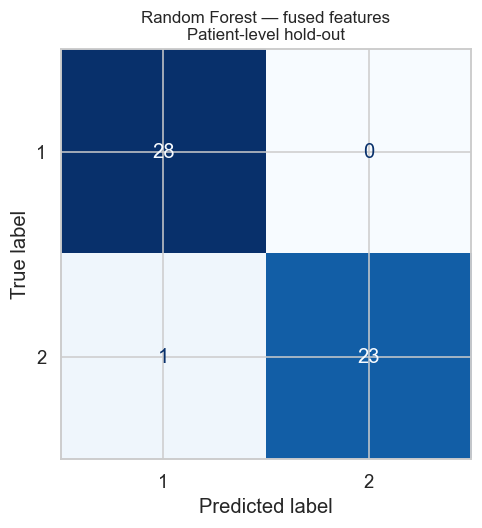

In [18]:
# Split at patient level to prevent data leakage from repeated measures
unique_patients = df['Patient_ID'].unique()
pts_train, pts_test = sklearn.model_selection.train_test_split(
    unique_patients, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
train_idx = df[df['Patient_ID'].isin(pts_train)].index
test_idx  = df[df['Patient_ID'].isin(pts_test)].index

X_tr, X_te = X_fused[train_idx], X_fused[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]

# Best model from CV (fused feature set)
best_row   = results_df[results_df['features'] == 'fused'].sort_values('mean', ascending=False).iloc[0]
best_model = copy.deepcopy(models[best_row['model']])
best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_te)

print(f'Best model (CV): {best_row["model"]}  BalAcc={best_row["mean"]:.4f} ± {best_row["std"]:.4f}')
print(f'\nHold-out Balanced Accuracy : {sklearn.metrics.balanced_accuracy_score(y_te, y_pred):.4f}')
print(f'Hold-out Accuracy          : {sklearn.metrics.accuracy_score(y_te, y_pred):.4f}')
print('\nClassification Report:')
print(sklearn.metrics.classification_report(
    y_te, y_pred, target_names=[str(c) for c in le.classes_]
))

fig, ax = plt.subplots(figsize=(6, 5))
cm   = sklearn.metrics.confusion_matrix(y_te, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels=[str(c) for c in le.classes_])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{best_row["model"]} — fused features\nPatient-level hold-out', fontsize=11)
plt.tight_layout(); plt.show()